# Amazon E-Commerce Sales Analysis

In [1]:
# importing the required libraries.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# reading the data.

data=pd.read_csv('SuperStoreOrders.csv')

In [3]:
# copying the data from source to keep data backup.

df=data.copy()

In [4]:
# quick data frame analysis.

pd.set_option('display.max_columns',None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [5]:
# checking the for null value.

df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [6]:
# doing quick analysis on the numeric columns.

df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [7]:
# doing quick analysis on non-numerical columns.

df.describe(include='object')

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,order_priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,1430,1464,4,795,3,1094,147,7,13,10292,3,17,3788,2246,4
top,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,Muhammed Yedwab,Consumer,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,13,Medium
freq,14,135,130,30775,108,26518,2001,9994,11002,11117,35,31273,6152,227,589,29433


In [8]:
# data type conversion of columns.

df['sales'] = df['sales'].astype(str).str.replace(',', '')
df['sales'] =pd.to_numeric(df['sales'],errors='coerce')
df['order_date']=pd.to_datetime(df['order_date'],format='mixed',dayfirst=True)
df['ship_date']=pd.to_datetime(df['ship_date'],format='mixed',dayfirst=True)
Category = [
    'ship_mode', 'segment', 'country', 'market', 
    'region', 'category', 'sub_category', 'order_priority'
]
for col in Category:
    df[col] = df[col].astype('category')
df['year']=df['order_date'].dt.year.astype('int16')

In [9]:
# checking the columns and their columns.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  category      
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  category      
 6   state           51290 non-null  object        
 7   country         51290 non-null  category      
 8   market          51290 non-null  category      
 9   region          51290 non-null  category      
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  category      
 12  sub_category    51290 non-null  category      
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [10]:
# checking for the duplicated rows.

df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
51285    False
51286    False
51287    False
51288    False
51289    False
Length: 51290, dtype: bool

In [11]:
# dropping the duplicated rows.

df.drop_duplicates()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-01-04,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,2014-12-31,2015-01-05,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,2014-12-31,2015-01-06,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [12]:
# checking the data by extracting the first 5 rows of data from the data set.

df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [13]:
# checking the data by extracting the last 5 rows of data from the data set.

df.tail()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
51285,CA-2014-115427,2014-12-31,2015-01-04,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,2014-12-31,2015-01-05,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,2014-12-31,2015-01-06,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
51289,CA-2014-156720,2014-12-31,2015-01-04,Standard Class,Jill Matthias,Consumer,Colorado,United States,US,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3,3,0.2,-0.6048,0.17,Medium,2014


In [14]:
# Total Revenue generated across all regions

total_revenue=df['sales'].sum()
print('Total Revenue: $',total_revenue)

Total Revenue: $ 12642905


In [15]:
# Total Profit earned by the company

total_profit=df['profit'].sum()
print('Total Profit: $',total_profit)

Total Profit: $ 1469034.82128


In [16]:
# Total unique customers who placed orders

unique_customers=df['customer_name'].nunique()
print('Unique Customers: ',unique_customers)

Unique Customers:  795


In [17]:
# Total quantity of products sold

total_quantity=df['quantity'].sum()
print('Total Quantity sold:',total_quantity)

Total Quantity sold: 178312


In [18]:
# Average price of products in the dataset

df['unit_price']=(df['sales']/(1-df['discount']))/df['quantity']
avg_price=df.groupby('product_name')['unit_price'].mean().mean()
print('Average Price of the product:',avg_price)

Average Price of the product: 101.85688713854329


In [19]:
# Top 5 best-selling products by quantity

top_5=df.groupby('product_name')['quantity'].sum().nlargest(5)
print('Top 5 product by quantity:',top_5)

Top 5 product by quantity: product_name
Staples                                  876
Cardinal Index Tab, Clear                337
Eldon File Cart, Single Width            321
Rogers File Cart, Single Width           262
Sanford Pencil Sharpener, Water Color    259
Name: quantity, dtype: int64


In [20]:
# Product category generating highest revenue

revenue_by_category=df.groupby('category',observed=False)['sales'].sum()
print('Top Category by their revenue')
print(revenue_by_category.apply(lambda x:f"${x:2f}"))

Top Category by their revenue
category
Furniture          $4110884.000000
Office Supplies    $3787330.000000
Technology         $4744691.000000
Name: sales, dtype: object


In [21]:
# Category with the lowest profit margin


category=df.groupby('category',observed=False)[['sales','profit']].sum()
category['profit_margin']=(category['profit']/category['sales'])*100
lowest_sort=category['profit_margin'].sort_values()
print('Category with the lowest profit margin')
print(lowest_sort.apply(lambda x:f"{x:.2f}%"))

Category with the lowest profit margin
category
Furniture           6.98%
Office Supplies    13.69%
Technology         13.99%
Name: profit_margin, dtype: object


In [22]:
# Number of unique products per category

unique_products=df['product_name'].nunique()
print("Unique Products")
print(unique_products)

Unique Products
3788


In [23]:
#  Specific product resulting in highest loss

lowest_profit=df['profit'].idxmin()
high_loss=df.loc[lowest_profit]
print(high_loss['product_name'],':',high_loss['profit'])

Cubify CubeX 3D Printer Double Head Print : -6599.978


In [24]:
# month that had the highest sales peak

df['Year_month']=df['order_date'].dt.to_period('M')
month=df.groupby('Year_month')['sales'].sum()
peak_period=month.idxmax()
peak_sales=month.max()
print(f"highest sales month:{peak_period} and sales ${peak_sales}")

highest sales month:2014-11 and sales $555312


In [25]:
# Monthly growth rate percentage

df['Year_month']=df['order_date'].dt.to_period('M')
month=df.groupby('Year_month')['sales'].sum()
monthly_growth = month.pct_change() * 100
dataframe=pd.DataFrame({
	"Total Sales":month.apply(lambda x:f"{x:,.2f}%"),
	"MOM Growth Rate": monthly_growth.apply(lambda x:f"{x:+.2f}%" if pd.notnull(x) else 'N/A')
})
print(dataframe)

            Total Sales MOM Growth Rate
Year_month                             
2011-01      98,902.00%             N/A
2011-02      91,152.00%          -7.84%
2011-03     145,726.00%         +59.87%
2011-04     116,927.00%         -19.76%
2011-05     146,762.00%         +25.52%
2011-06     215,214.00%         +46.64%
2011-07     115,518.00%         -46.32%
2011-08     207,570.00%         +79.69%
2011-09     290,230.00%         +39.82%
2011-10     199,070.00%         -31.41%
2011-11     298,499.00%         +49.95%
2011-12     333,941.00%         +11.87%
2012-01     135,775.00%         -59.34%
2012-02     100,521.00%         -25.97%
2012-03     163,092.00%         +62.25%
2012-04     161,060.00%          -1.25%
2012-05     208,370.00%         +29.37%
2012-06     256,181.00%         +22.95%
2012-07     145,247.00%         -43.30%
2012-08     303,158.00%        +108.72%
2012-09     289,390.00%          -4.54%
2012-10     252,942.00%         -12.59%
2012-11     323,512.00%         +27.90%


In [26]:
# Busiest day of the week for order

df['Days_of_weeks']=df['order_date'].dt.day_name()
busiest_day=df.groupby('Days_of_weeks')['order_id'].nunique().sort_values(ascending=False)
print(busiest_day)

Days_of_weeks
Tuesday      4632
Monday       4614
Friday       4608
Wednesday    4537
Thursday     4433
Saturday     2323
Sunday        482
Name: order_id, dtype: int64


In [27]:
# Average delivery time (Days)

delivery_difference=df['ship_date']-df['order_date']
df['delivery_days']=delivery_difference.dt.days
avg=df['delivery_days'].mean()
rough=round(avg)
print('Average delay of delivery: ',rough,'days')

Average delay of delivery:  4 days


In [28]:
# Q4 outperform Q1 in revenue

df['quarter'] = df['order_date'].dt.quarter
quarterly_revenue = df.groupby('quarter')['sales'].sum()
q1_revenue = quarterly_revenue.get(1, 0)
q4_revenue = quarterly_revenue.get(4, 0)
print("--- Revenue Breakdown by Quarter ---")
for qtr, rev in quarterly_revenue.items():
    print(f"Q{qtr}: ${rev:,.2f}")
print("\n--- The Verdict ---")
if q4_revenue > q1_revenue:
    difference = q4_revenue - q1_revenue
    print(f"Yes! Q4 outperformed Q1 by ${difference:,.2f}.")
else:
    difference = q1_revenue - q4_revenue
    print(f"No! Q1 outperformed Q4 by ${difference:,.2f}.")

--- Revenue Breakdown by Quarter ---
Q1: $1,989,428.00
Q2: $2,872,415.00
Q3: $3,480,707.00
Q4: $4,300,355.00

--- The Verdict ---
Yes! Q4 outperformed Q1 by $2,310,927.00.


In [29]:
#  Region with highest contribution to sales

regional=df.groupby('region',observed=False)['sales'].sum()
regional_order=regional.sort_values(ascending=False)
print(regional_order.apply(lambda x: f"{x:.2f}$"))

region
Central           2822399.00$
South             1600960.00$
North             1248192.00$
Oceania           1100207.00$
Southeast Asia     884438.00$
North Asia         848349.00$
EMEA               806184.00$
Africa             783776.00$
Central Asia       752839.00$
West               725514.00$
East               678834.00$
Caribbean          324281.00$
Canada              66932.00$
Name: sales, dtype: object


In [30]:
# Top 10 cities by customer count

populated_city=df['state'].value_counts().head(10).reset_index()
populated_city.columns=['state','customer_name']
print(populated_city)

                    state  customer_name
0              California           2001
1                 England           1499
2                New York           1128
3                   Texas            985
4           Ile-de-France            981
5         New South Wales            781
6  North Rhine-Westphalia            719
7              Queensland            717
8            San Salvador            615
9            Pennsylvania            587


In [31]:
# Average Order Value (AOV) per region

avg_order_value=df.groupby('region',observed=False)['sales'].mean().reset_index()
avg_order_value.columns=['region','Average Order Value']
avg_order_value.style.format({'Average Order Value':'${:,.2f}'})

,region,Average Order Value
0,Africa,$170.87
1,Canada,$174.30
2,Caribbean,$191.88
3,Central,$253.88
4,Central Asia,$367.60
5,EMEA,$160.31
6,East,$238.35
7,North,$260.86
8,North Asia,$362.85
9,Oceania,$315.52


In [32]:
# Region with highest avg discount

region_wise_avg_discount=df.groupby('region',observed=False)['discount'].mean().reset_index()
region_wise_avg_discount.columns=['region','Average Discount']
region_wise_avg_discount.style.format({'Average Discount':'${:.2f}'})

,region,Average Discount
0,Africa,$0.16
1,Canada,$0.00
2,Caribbean,$0.14
3,Central,$0.14
4,Central Asia,$0.07
5,EMEA,$0.20
6,East,$0.15
7,North,$0.10
8,North Asia,$0.05
9,Oceania,$0.15


In [33]:
# Percentage of Repeat vs One-time buyers
customers_order_count=df.groupby('customer_name')['order_id'].nunique()
repeated_buyer=customers_order_count>1
share_of_repeated=repeated_buyer.value_counts(normalize=True)
share_of_repeated.index=share_of_repeated.index.map({True:'Repeated Buyer',False:'One Time Buyer'})
percentage=(share_of_repeated*100).round(2).astype(str)+'%'
print(percentage)

order_id
Repeated Buyer    100.0%
Name: proportion, dtype: object


In [34]:
#  Correlation between Discount and Profit

corr=df[['discount','profit']].corr()
corr

,discount,profit
discount,1.000000,-0.316375
profit,-0.316375,1.000000


In [35]:
# shipment mode method with fastest delivery

delivery_speed=df.groupby('ship_mode',observed=False)['delivery_days'].mean().reset_index()
delivery_speed.columns = ['ship_mode','Average Delivery Days']
delivery_speed_sorted=delivery_speed.sort_values(by='Average Delivery Days',ascending=False)
print(delivery_speed_sorted)

        ship_mode  Average Delivery Days
3  Standard Class               4.998018
2    Second Class               3.230187
0     First Class               2.181746
1        Same Day               0.037394


In [36]:
# Products with high sales but negative profit

threshold=df['sales'].quantile(0.75)
loss_maker=df[(df['sales']>threshold) & (df['profit']<0)]
problem_products=loss_maker[['product_name','category','sales','profit']].sort_values(by='profit')
print(f"Threshold Value: ${threshold}")
print(problem_products.head(10))

Threshold Value: $251.0
                                    product_name         category  sales  \
31884  Cubify CubeX 3D Printer Double Head Print       Technology   4500   
29212             Motorola Smart Phone, Cordless       Technology   3085   
47195  Cubify CubeX 3D Printer Triple Head Print       Technology   8000   
3775   GBC DocuBind P400 Electric Binding System  Office Supplies   2178   
37130  Lexmark MX611dhe Monochrome Laser Printer       Technology   2550   
24286                        Hoover Stove, White  Office Supplies   3400   
28510               Apple Smart Phone, Full Size       Technology   3499   
49628       Ibico EPK-21 Electric Binding System  Office Supplies   1890   
34513     Barricks Conference Table, Rectangular        Furniture   2171   
19251  Cubify CubeX 3D Printer Double Head Print       Technology   1800   

          profit  
31884 -6599.9780  
29212 -4088.3760  
47195 -3839.9904  
3775  -3701.8928  
37130 -3399.9800  
24286 -3059.8200  
28510 

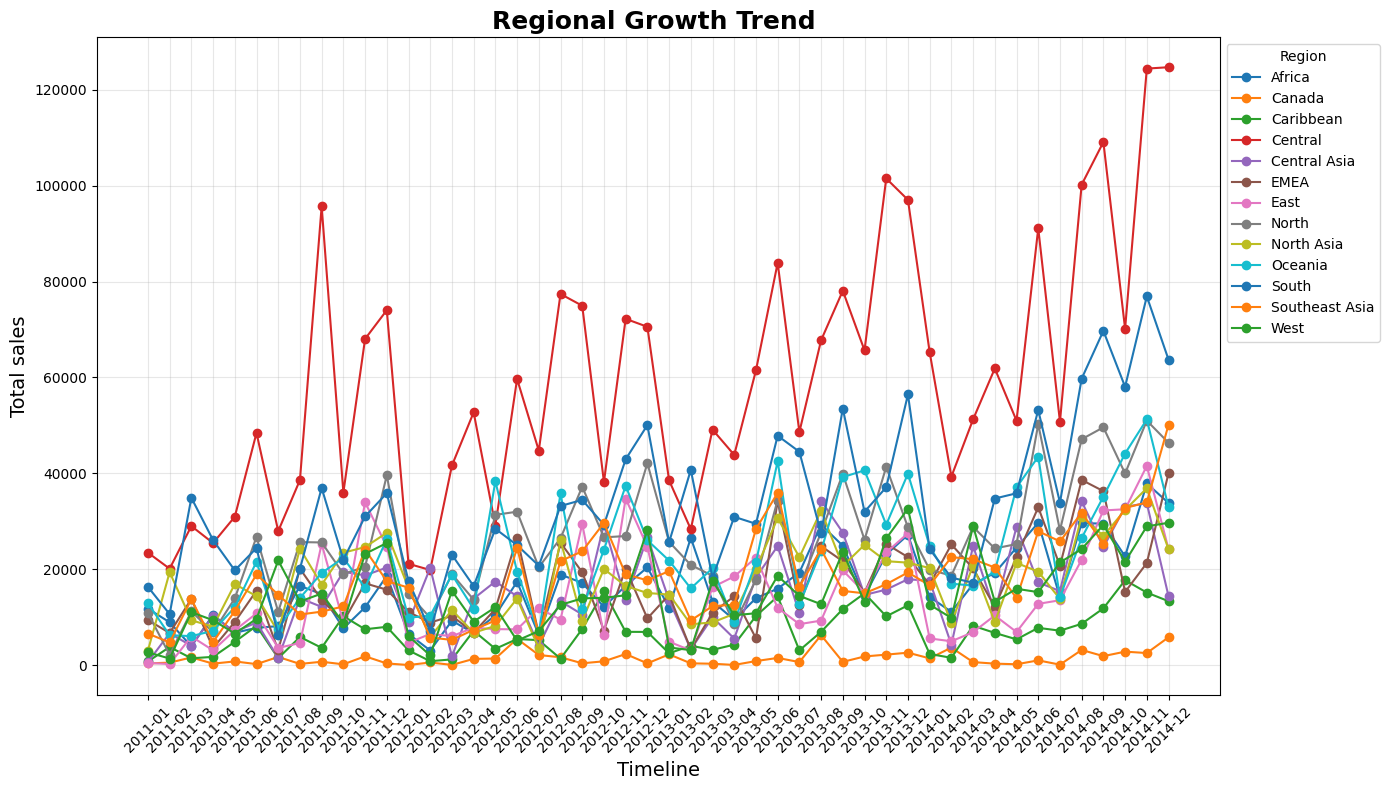

In [37]:
# Most consistent regional growth trend

group_region=df.groupby(['Year_month','region'],observed=False)['sales'].sum().reset_index()
group_region['Year_month']=group_region['Year_month'].astype(str)
pivot=group_region.pivot(index='Year_month',columns='region',values='sales')
plt.figure(figsize=(14,8))
plt.plot(pivot.index,pivot.values,marker='o')
plt.title('Regional Growth Trend ',fontsize=18,fontweight='bold')
plt.xlabel('Timeline',fontsize=14)
plt.ylabel('Total sales',fontsize=14)
plt.xticks(rotation=45)
plt.legend(pivot.columns,title='Region',bbox_to_anchor=(1,1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()